# Medical Appointment No-Shows Analysis

## Table of Contents
- [Introduction](#introduction)
- [Data Wrangling](#data-wrangling)
- [Exploratory Data Analysis](#exploratory-data-analysis)
- [Conclusions](#conclusions)

## Introduction

### Data Source
Dataset: No-show appointments dataset from Kaggle
URL: https://www.kaggle.com/joniarroba/noshowappointments

### Dataset Description
This dataset contains 110,527 medical appointment records from Brazil in 2016. 
Each row represents one appointment with the following key columns:

- **PatientId**: Unique identifier for each patient
- **AppointmentID**: Unique identifier for each appointment
- **Gender**: Patient gender (M/F)
- **ScheduledDay**: The day the appointment was scheduled
- **AppointmentDay**: The day of the actual appointment
- **Age**: Patient age
- **Neighbourhood**: Location of the appointment
- **Scholarship**: Whether patient is enrolled in welfare program (1=yes, 0=no)
- **Hipertension**: Whether patient has hypertension (1=yes, 0=no)
- **Diabetes**: Whether patient has diabetes (1=yes, 0=no)
- **Alcoholism**: Whether patient has alcoholism (1=yes, 0=no)
- **Handcap**: Whether patient has a handicap (1=yes, 0=no)
- **SMS_received**: Whether patient received an SMS reminder (1=yes, 0=no)
- **No-show**: Whether patient missed their appointment (1=no show, 0=showed up)

### Questions for Analysis
1. Does receiving an SMS reminder reduce no-shows?
2. Does age affect whether patients show up?
3. Do patients with chronic conditions show up more reliably?

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Data Wrangling

### General Properties
Here, the dataset is loaded, inspected, and cleaned in order to begin analysis.

In [2]:
appt = pd.read_csv('noshowappointments-kagglev2-may-2016.csv')
appt.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
# get dataset dimensions
appt.shape

(110527, 14)

In [4]:
# show column summary
appt.describe(include = 'all')

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
count,1.105270e+05,1.105270e+05,110527,110527,110527,110527.000000,110527,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527
unique,NaN,NaN,2,103549,27,NaN,81,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,F,2016-05-06T07:09:54Z,2016-06-06T00:00:00Z,NaN,JARDIM CAMBURI,NaN,NaN,NaN,NaN,NaN,NaN,No
freq,NaN,NaN,71840,24,4692,NaN,7717,NaN,NaN,NaN,NaN,NaN,NaN,88208
mean,1.474963e+14,5.675305e+06,NaN,NaN,NaN,37.088874,NaN,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026,NaN
std,2.560949e+14,7.129575e+04,NaN,NaN,NaN,23.110205,NaN,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873,NaN
min,3.921784e+04,5.030230e+06,NaN,NaN,NaN,-1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,4.172614e+12,5.640286e+06,NaN,NaN,NaN,18.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,3.173184e+13,5.680573e+06,NaN,NaN,NaN,37.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,9.439172e+13,5.725524e+06,NaN,NaN,NaN,55.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN


In [5]:
# Check shape, data types, and missing values
print("Shape:", appt.shape)
print("\nData Types:\n", appt.dtypes)
print("\nMissing Values:\n", appt.isnull().sum())
print("\nBasic Statistics:\n", appt.describe())

Shape: (110527, 14)

Data Types:
 PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object

Missing Values:
 PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

Basic Statistics:
           PatientId  AppointmentID            Age    Scholarship  \
count  1.105270e+05   1.105270e+05  110527.000000  110527.000000   
mean   1.474963e+14   5.675305e+06      37.088874       0.098266   
std    2.560949e+14   7.129575e+04      23.110205    

### Data Cleaning
The following cleaning steps were performed:

- **Dropped 5 columns** not relevant for analysis: PatientId, AppointmentID, 
  ScheduledDay, AppointmentDay, and Neighbourhood
- **Removed 1 row** where Age = -1 (impossible value), leaving 110,526 records
- **Converted No-show** column from Yes/No text to binary values 
  (1 = no show, 0 = showed up) for easier calculations

In [6]:
# Data cleaning steps

# Drop columns not relevant to our questions
appt = appt.drop(['PatientId', 'AppointmentID', 'ScheduledDay', 
              'AppointmentDay', 'Neighbourhood'], axis=1)

# Remove -1 age value
print("Rows before cleaning:", len(appt))
appt = appt[appt['Age'] >= 0]
print("Rows after cleaning:", len(appt))

# Convert No-show from Yes/No to 1/0 for easier calculations
appt['No-show'] = (appt['No-show'] == 'Yes').astype(int)

# Confirm changes
print("\nCleaned Data Shape:", appt.shape)
print("\nNo-show value counts:\n", appt['No-show'].value_counts())

Rows before cleaning: 110527
Rows after cleaning: 110526

Cleaned Data Shape: (110526, 9)

No-show value counts:
 No-show
0    88207
1    22319
Name: count, dtype: int64


## Exploratory Data Analysis

First, we will define a reusable plotting function that will be used for all three analyses below.


### Research Question 1 - Does receiving an SMS reminder reduce appointment no-shows?

In [7]:
# Create reusable function to create bar charts
def appt_noshow_rate(categories, rates, title, xlabel, ylabel='No-Show Rate'):
    plt.figure(figsize=(8, 5))
    plt.bar(categories, rates, color='limegreen', edgecolor='black')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'{x:.0%}'))
    plt.tight_layout()
    plt.show()

# No-show rate overall
overall_rate = appt['No-show'].mean()
print(f"Overall no-show rate: {overall_rate:.2%}")

Overall no-show rate: 20.19%


Rate of No-shows by SMS:
 SMS_received
0    0.167035
1    0.275745
Name: No-show, dtype: float64


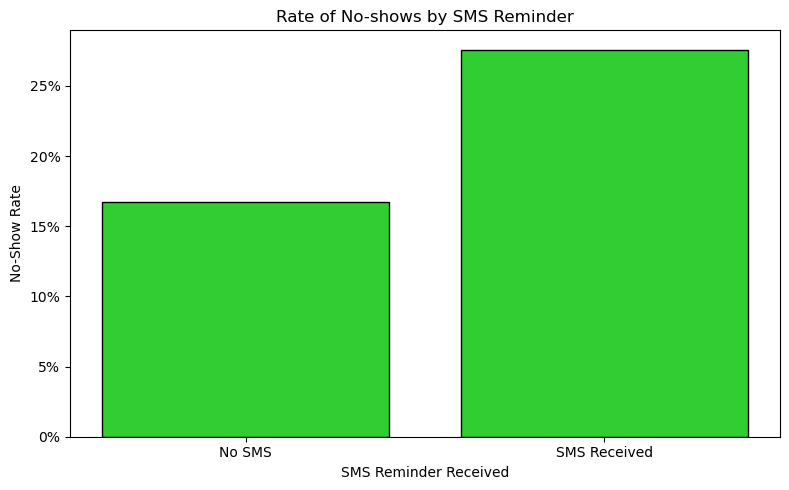

In [8]:
# Calculate no-show rate by SMS received
sms_noshow = appt.groupby('SMS_received')['No-show'].mean()
print("Rate of No-shows by SMS:\n", sms_noshow)

# Plot using reusable function
appt_noshow_rate(
    categories=['No SMS', 'SMS Received'],
    rates=sms_noshow.values,
    title='Rate of No-shows by SMS Reminder',
    xlabel='SMS Reminder Received'
)

Interestingly, the no-show rate was higher among patients who received SMS reminders (27.6%) than among those who did not (16.7%).

### Research Question 2 - Does age affect whether patients show up?

No-show rate by age group:
 age_group
0-18     0.225372
19-35    0.238348
36-55    0.197075
56+      0.156450
Name: No-show, dtype: float64


/var/folders/cw/5dh0bjcn4qs9szxvtmslq0rh0000gn/T/ipykernel_84456/1203528898.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_noshow = appt.groupby('age_group')['No-show'].mean()


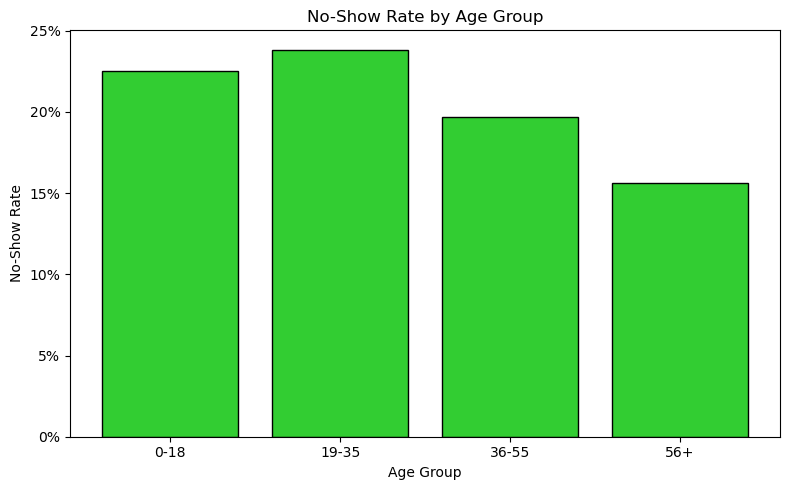

In [9]:
# Create age group sections and sort each appointment into the right category
bins = [0, 18, 35, 55, 115]
labels = ['0-18', '19-35', '36-55', '56+']
appt['age_group'] = pd.cut(appt['Age'], bins=bins, labels=labels)

# No-show rate by age group
age_noshow = appt.groupby('age_group')['No-show'].mean()
print("No-show rate by age group:\n", age_noshow)

appt_noshow_rate(
    categories=labels,
    rates=age_noshow.values,
    title='No-Show Rate by Age Group',
    xlabel='Age Group'
)

The highest no-show rate, 23.8% was seen among younger patients aged 19-35, whereas older patients aged 56 and older were more dependable, with a no-show rate of just 15.6%.

/var/folders/cw/5dh0bjcn4qs9szxvtmslq0rh0000gn/T/ipykernel_84456/2682802245.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bivariate = appt.groupby(['age_group', 'SMS_received'])['No-show'].mean().unstack()


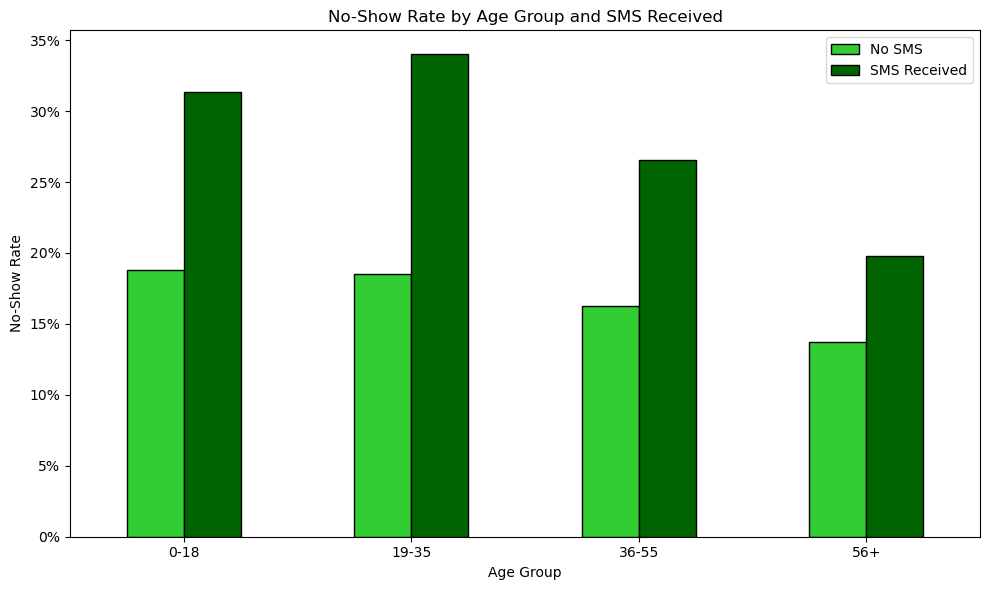

In [10]:
bivariate = appt.groupby(['age_group', 'SMS_received'])['No-show'].mean().unstack()

bivariate.plot(kind='bar', figsize=(10,6), color=['limegreen', 'darkgreen'], edgecolor='black')
plt.title('No-Show Rate by Age Group and SMS Received')
plt.xlabel('Age Group')
plt.ylabel('No-Show Rate')
plt.xticks(rotation=0)
plt.legend(['No SMS', 'SMS Received'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

Across all age groups, the pattern is similar: patients who received SMS reminders consistently had higher no-show rates than those who did not. The widest gap between the two groups occurred among patients aged 19–35. This indicates that the unexpected link between SMS reminders and higher rates of missed appointments is not concentrated in any one age group, but rather reflects a consistent trend throughout the dataset.

### Research Question 3 - Do patients with chronic conditions (hypertension or diabetes) show up more or less reliably?

No-show rate by Hypertension:
 Hipertension
0    0.209039
1    0.173020
Name: No-show, dtype: float64

No-show rate by Diabetes:
 Diabetes
0    0.203630
1    0.180033
Name: No-show, dtype: float64


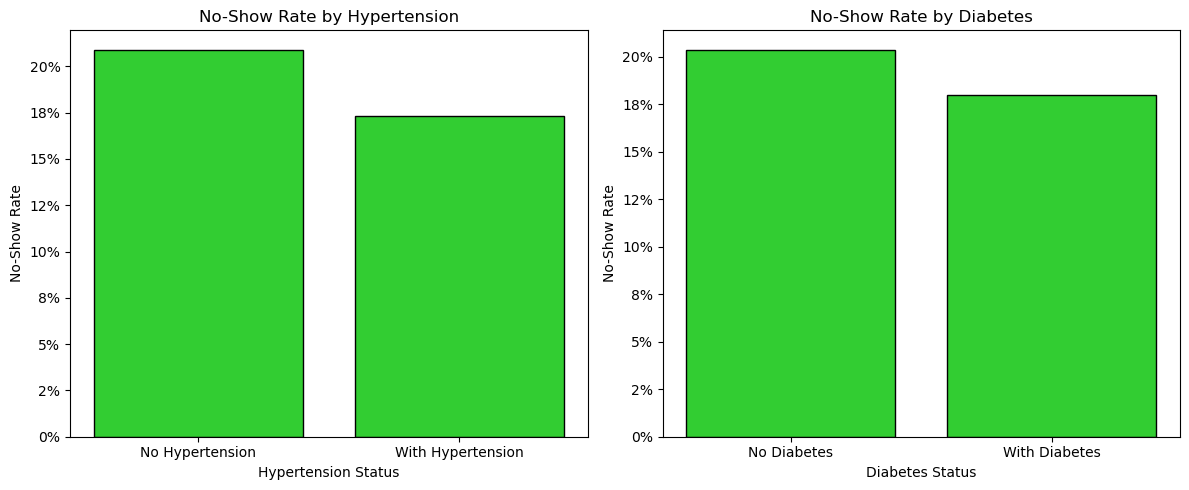

In [11]:
# No-show rate by condition category (hypertension or diabetes)
hyp_noshow = appt.groupby('Hipertension')['No-show'].mean()
diab_noshow = appt.groupby('Diabetes')['No-show'].mean()

print("No-show rate by Hypertension:\n", hyp_noshow)
print("\nNo-show rate by Diabetes:\n", diab_noshow)

# Plot each category chart side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(['No Hypertension', 'With Hypertension'], hyp_noshow.values, color='limegreen', edgecolor='black')
ax1.set_title('No-Show Rate by Hypertension')
ax1.set_xlabel('Hypertension Status')
ax1.set_ylabel('No-Show Rate')

ax2.bar(['No Diabetes', 'With Diabetes'], diab_noshow.values, color='limegreen', edgecolor='black')
ax2.set_title('No-Show Rate by Diabetes')
ax2.set_xlabel('Diabetes Status')
ax2.set_ylabel('No-Show Rate')

ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

Patients with hypertension had a lower no-show rate (17.3%) compared to those 
without (20.9%). Similarly, diabetic patients missed fewer appointments (18.0%) 
than non-diabetic patients (20.4%). 

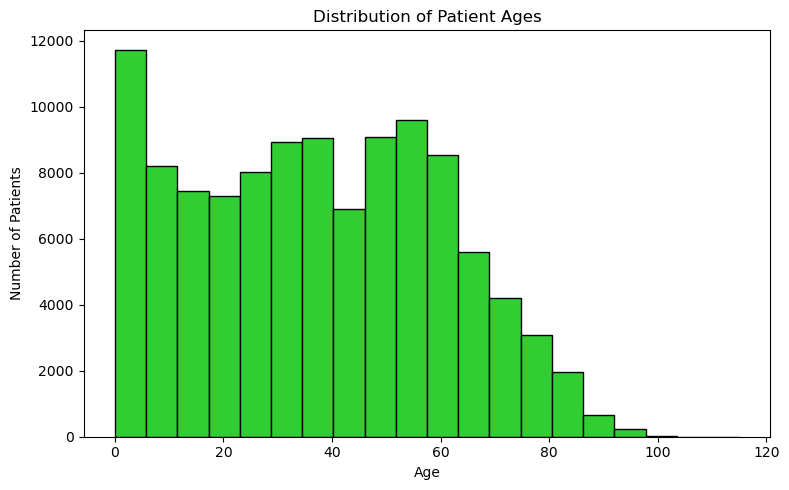

Average patient age: 37.1
Median patient age: 37.0


In [12]:
# Distribution of patient ages
plt.figure(figsize=(8, 5))
plt.hist(appt['Age'], bins=20, color='limegreen', edgecolor='black')
plt.title('Distribution of Patient Ages')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

print("Average patient age:", round(appt['Age'].mean(), 1))
print("Median patient age:", appt['Age'].median())

The distribution of patient ages shows that the average and median age are both approximately 37 years. There is a notable spike in appointments for patients aged 0-5, likely reflecting routine pediatric checkups. The large dataset of 110,526 appointments provides a reliable basis for identifying patterns across age groups.

## Conclusions

An analysis of 110,526 medical appointments in Brazil revealed three key patterns related to patients not showing up for their appointments.

**Key Findings:**
- Patients who received SMS reminders actually had a higher rate of missed appointments (27.6%) than those who did not (16.7%).
- Age was strongly associated with attendance: younger adults (ages 19–35) missed appointments most often (23.8%), while patients aged 56 and older were the most reliable (15.6%).
- Individuals with chronic conditions demonstrated better attendance. Specifically, patients with hypertension (17.3% no-show rate) and diabetes (18.0%) were less likely to miss appointments than those without such conditions.

**Limitations:**
- The findings reflect correlations only, not cause and effect. For instance, the data do not necessarily prove that SMS reminders led to higher no-show rates.
- The data come from a single Brazilian dataset collected in 2016, so results may not apply to other healthcare settings or more recent timeframes.
- Important variables, such as the length of time between scheduling and the appointment, were not examined and could potentially explain some of the observed trends.


**Future Research:**
- Investigating the role of wait times where the patient misses their appointment would help clarify the unexpected association between SMS reminders and missed appointments.

### Resources
The following documentation was referenced during this analysis:

- Pandas documentation: https://pandas.pydata.org/docs/
- Matplotlib documentation: https://matplotlib.org/stable/index.html
- NumPy documentation: https://numpy.org/doc/